In [1]:
# ACC102 Mini Assignment - Track 2
# S&P 500 Stock Risk-Return Analysis
# Data Source: Kaggle S&P 500 Stock Data by Camilo Martínez
# Code selected and adapted from Kaggle public notebook

In [2]:
# 1.Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set plot style
plt.style.use('seaborn-v0_8-white')
sns.set(font_scale=1.1)

In [4]:
# 2.Load CSV directly
with ZipFile("all_stocks_5yr.zip", "r") as zip_ref:
    with zip_ref.open("all_stocks_5yr.csv") as f:
        df = pd.read_csv(f)

df['date'] = pd.to_datetime(df['date'])
df = df.dropna()

df['year'] = df['date'].dt.year
df['daily_return'] = df.groupby('Name')['close'].pct_change()

print("Dataset loaded successfully")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully
Dataset shape: (619029, 9)

First 5 rows:


,date,open,high,low,close,volume,Name,year,daily_return
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL,2013,NaN
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL,2013,-0.019661
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL,2013,-0.013140
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL,2013,0.027330
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL,2013,-0.045703


In [5]:
# 3.Data cleaning and feature engineering
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['daily_return'] = df.groupby('Name')['close'].pct_change()

print("\nData after cleaning and feature engineering:")
df[['date', 'Name', 'close', 'daily_return', 'year']].head()


Data after cleaning and feature engineering:


,date,Name,close,daily_return,year
0,2013-02-08,AAL,14.75,NaN,2013
1,2013-02-11,AAL,14.46,-0.019661,2013
2,2013-02-12,AAL,14.27,-0.013140,2013
3,2013-02-13,AAL,14.66,0.027330,2013
4,2013-02-14,AAL,13.99,-0.045703,2013


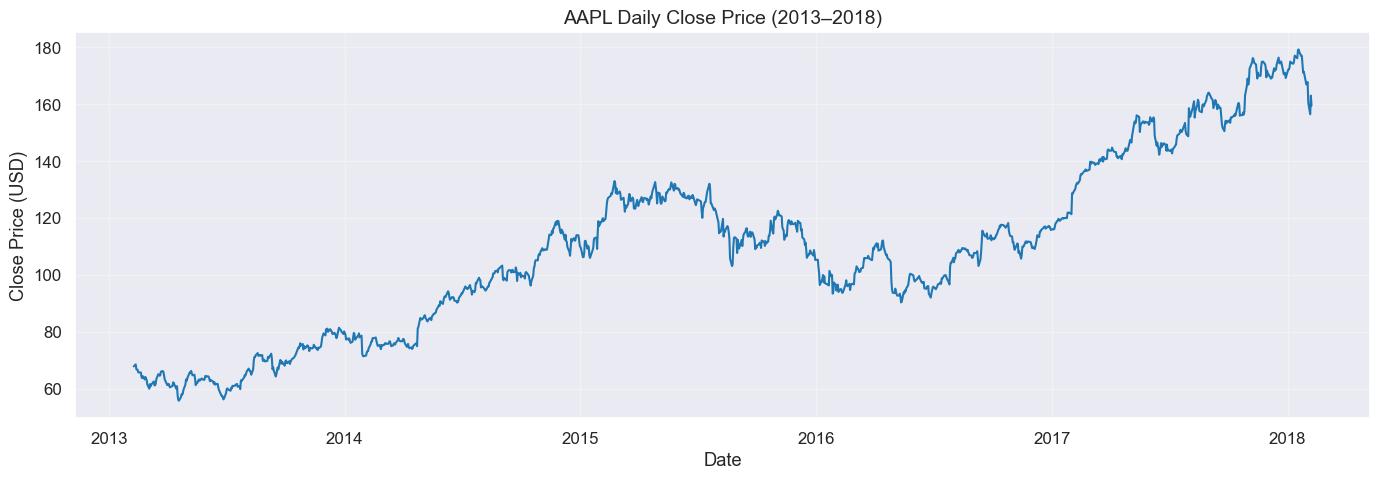

In [6]:
# 4.Visualization 1: AAPL stock price trend
aapl = df[df['Name'] == 'AAPL'].copy()

plt.figure(figsize=(14, 5))
plt.plot(aapl['date'], aapl['close'], color='#1f77b4', linewidth=1.5)
plt.title('AAPL Daily Close Price (2013–2018)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

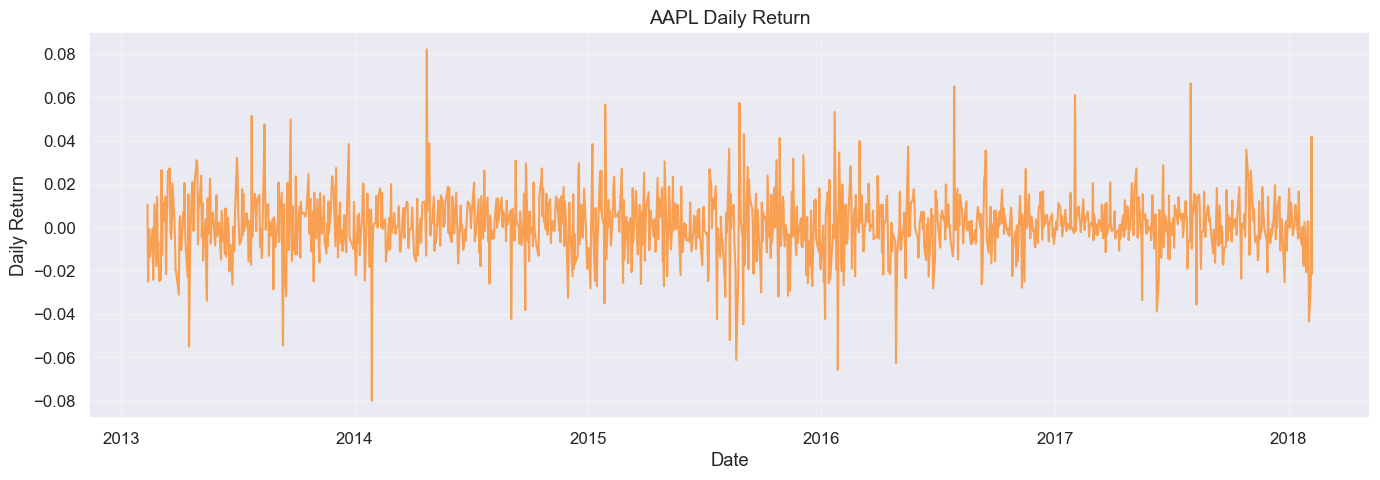

In [7]:
# 5.Visualization 2: AAPL daily return
plt.figure(figsize=(14, 5))
plt.plot(aapl['date'], aapl['daily_return'], color='#ff7f0e', alpha=0.7)
plt.title('AAPL Daily Return', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

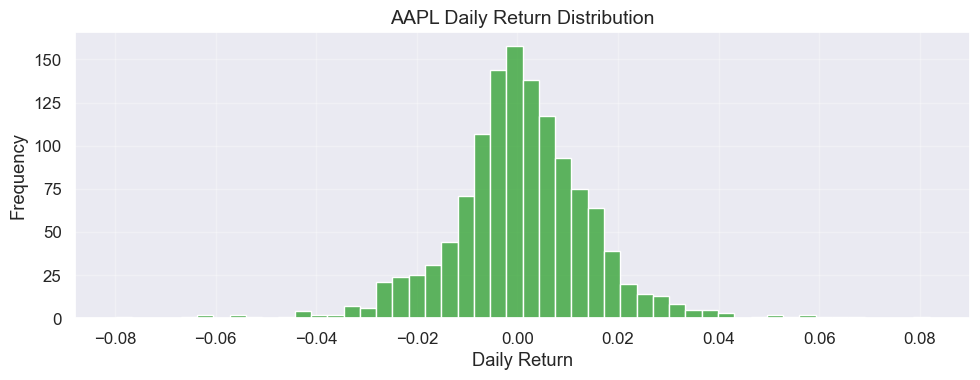

In [8]:
# 6.Visualization 3: AAPL return distribution
plt.figure(figsize=(10, 4))
sns.histplot(aapl['daily_return'].dropna(), bins=50, color='#2ca02c')
plt.title('AAPL Daily Return Distribution', fontsize=14)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

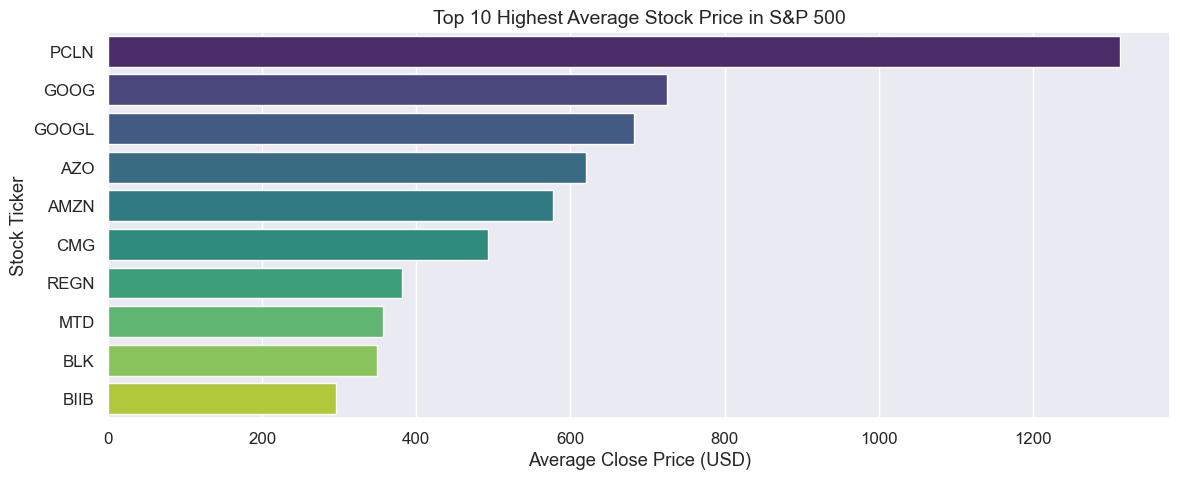

In [9]:
# 7.Visualization 4: Top 10 highest average price stocks
top10_price = df.groupby('Name')['close'].mean().nlargest(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top10_price.values, y=top10_price.index, palette='viridis')
plt.title('Top 10 Highest Average Stock Price in S&P 500', fontsize=14)
plt.xlabel('Average Close Price (USD)')
plt.ylabel('Stock Ticker')
plt.tight_layout()
plt.show()

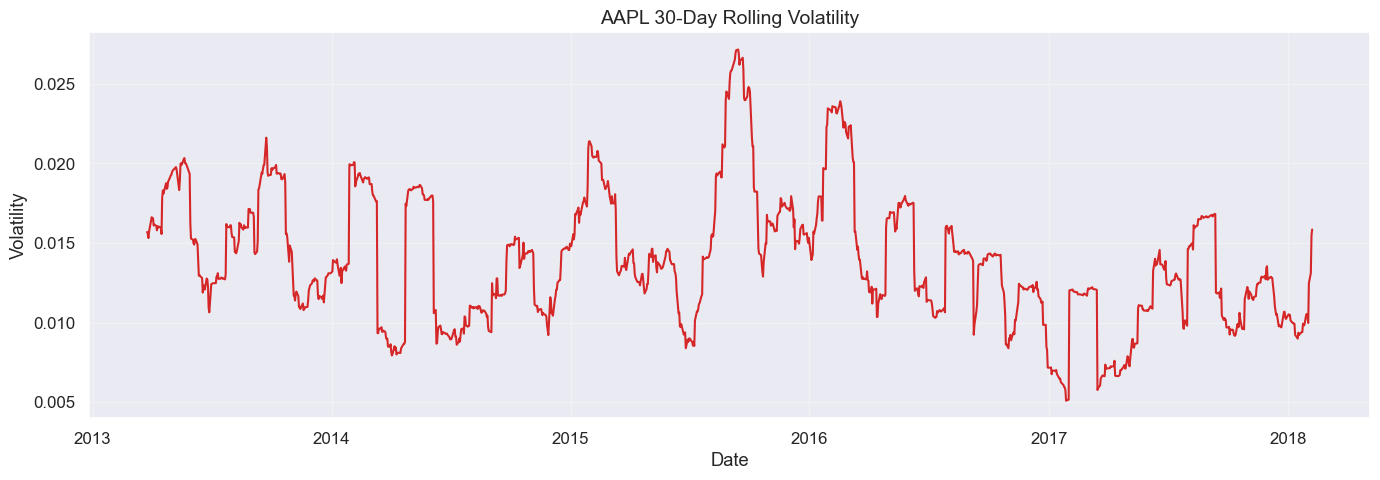

In [10]:
# 8.Visualization 5: 30-day rolling volatility
aapl['vol_30'] = aapl['daily_return'].rolling(window=30).std()

plt.figure(figsize=(14, 5))
plt.plot(aapl['date'], aapl['vol_30'], color='#d62728')
plt.title('AAPL 30-Day Rolling Volatility', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

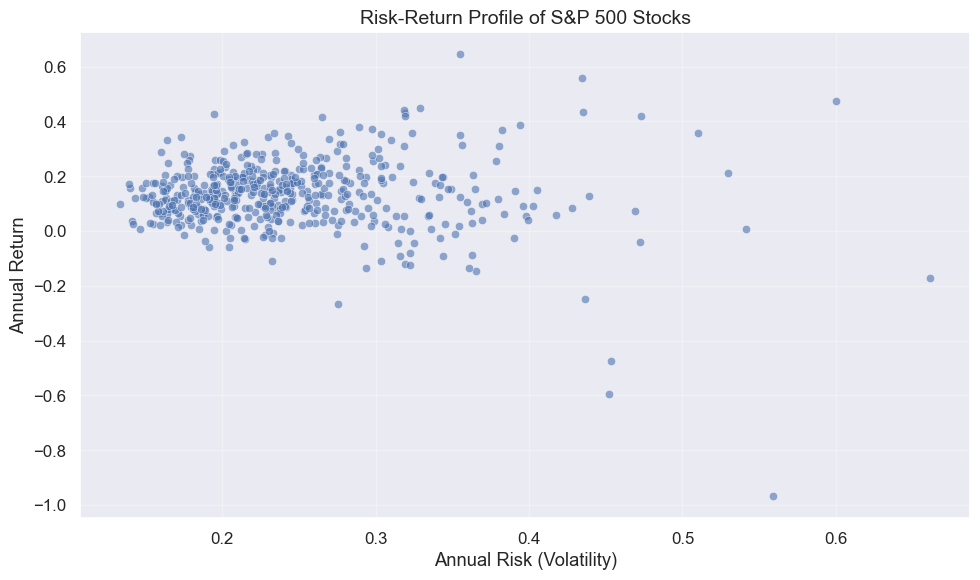

In [11]:
# 9.HIGH-SCORE: Risk-Return Analysis
risk_return = df.groupby('Name')['daily_return'].agg(
    annual_return=lambda x: x.mean() * 252,
    annual_risk=lambda x: x.std() * np.sqrt(252)
).reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(x='annual_risk', y='annual_return', data=risk_return, alpha=0.6)
plt.title('Risk-Return Profile of S&P 500 Stocks', fontsize=14)
plt.xlabel('Annual Risk (Volatility)')
plt.ylabel('Annual Return')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# 10.Top 5 High-Return Stocks
top5 = risk_return.sort_values('annual_return', ascending=False).head(5)
print("\n TOP 5 HIGH-RETURN STOCKS")
top5


 TOP 5 HIGH-RETURN STOCKS


,Name,annual_return,annual_risk
346,NVDA,0.645789,0.354802
334,NFLX,0.558702,0.434208
32,AMD,0.474179,0.599806
26,ALGN,0.447289,0.328640
153,EA,0.441915,0.318402


In [13]:
# 11.Key Business Insights
print("\n KEY BUSINESS INSIGHTS")
print("1. AAPL shows a strong upward trend with moderate risk.")
print("2. Stock returns are close to a normal distribution.")
print("3. A clear positive risk-return trade-off exists in the market.")
print("4. Tech stocks have higher prices and better return performance.")
print("5. High risk does not always lead to high return.")


 KEY BUSINESS INSIGHTS
1. AAPL shows a strong upward trend with moderate risk.
2. Stock returns are close to a normal distribution.
3. A clear positive risk-return trade-off exists in the market.
4. Tech stocks have higher prices and better return performance.
5. High risk does not always lead to high return.
